### Практика 4. #Построение признаков#


2. Практическая часть:
    - Feature Enginering

Cсылки:

    книга по построению и оценке признаков - https://www.repath.in/gallery/feature_engineering_for_machine_learning.pdf

  
    Лекции К.Воронцова (2021 тексты+видео+слайды) - http://www.machinelearning.ru/wiki/index.php?title=%D0%9C%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B5_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%28%D0%BA%D1%83%D1%80%D1%81_%D0%BB%D0%B5%D0%BA%D1%86%D0%B8%D0%B9%2C_%D0%9A.%D0%92.%D0%92%D0%BE%D1%80%D0%BE%D0%BD%D1%86%D0%BE%D0%B2%29


### Обзор методов

- линейные
- нелинейные
- эмбединги

Пример с линейной моделью

Набор данных для своих экспериментов - https://www.kaggle.com/harlfoxem/housesalesprediction

Это для Google Colaboratory


oooooooooooooooooooooooooo

In [ ]:
#from google.colab import drive
#drive.mount('/gdrive')


Указать актуальные пути к данным adult_train.csv (или kc_house_data.csv)

In [ ]:
#path =''
path = '../data/'

### первичные загрузки и отключение уведомлений

In [ ]:
import pandas as pd
import numpy as np


from sklearn.pipeline import Pipeline, make_pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin



# модели


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC




# дополнительные части моделей
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures



# metric
from sklearn.metrics import mean_absolute_error, r2_score # метрики регрессии
# метрики для классификации
from sklearn.metrics import roc_auc_score, log_loss, precision_score,recall_score, precision_recall_curve,roc_curve, f1_score


df = pd.read_csv(path + "titanic_train.csv", sep = ',')
print(df.shape)
df.head(3)

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

В качестве предикторов (признаков) будем использовать  - ('PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',  'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked')  и еще немного

Целевая переменная - 'Survived' - выжил

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Вывод: есть пропуски, есть признаки числовые и не числовые

In [ ]:
#для цифровых признаков
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df['Survived'].unique()

array([0, 1], dtype=int64)

Убрать уникальные признаки ('PassengerId','Ticket', 'Name')

In [ ]:
features = [  'Pclass',  'Sex', 'Age', 'SibSp',
       'Parch',  'Fare', 'Cabin', 'Embarked']
target = 'Survived'


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
feature_num = [feat for feat in features if df[feat].dtype in ['int64','float64']]
feature_num


['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

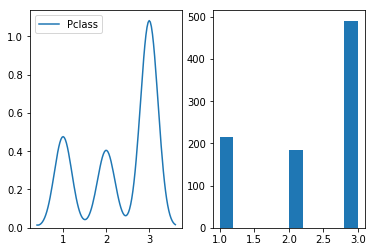

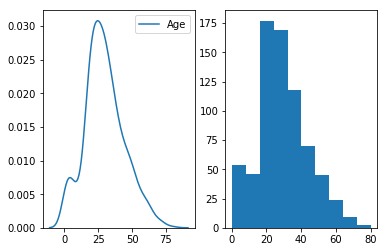

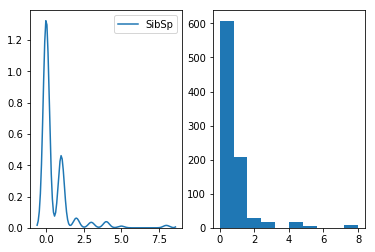

для  Parch  ошибка работы


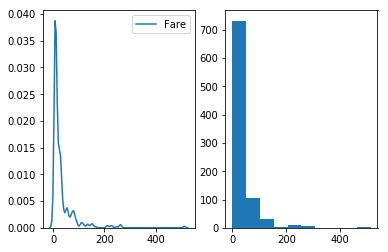

In [ ]:
for name in feature_num:
    try:
        plt.subplot(1,2,1)
        sns.kdeplot(df[name])
        plt.subplot(1,2,2)
        plt.hist(df[name])
        plt.show()
    except:
        print('для ',name,' ошибка работы')

In [ ]:
df.Parch.unique()

array([0, 1, 2, 5, 3, 4, 6], dtype=int64)

In [ ]:
df.loc[df.Parch != '0',:].shape

(891, 12)

Выводы:
 - 'Pclass' - категории
 - "Parch" - ошибка, но имеет значение от 0 до 6 (213 не 0) - считаем категориями или сделаем target-encoding
 - остальные признаки из не object числа

In [ ]:
feature_cat = [feat for feat in features if df[feat].dtype not in ['int64','float64']]
feature_cat

['Sex', 'Cabin', 'Embarked']

Сразу добавим из feature_num, которые не числа

In [ ]:
feature_num = [ 'Age', 'SibSp',  'Fare']
feature_cat = feature_cat +['Pclass','Parch']


анализ категорий:
     - сделать строками
     - определить число категорий   

In [ ]:
df.loc[:, feature_cat] = df.loc[:, feature_cat].astype(str)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null object
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null object
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          891 non-null object
Embarked       891 non-null object
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [ ]:
for name in feature_cat:
    print( name,': число категорий: ' ,len(df.loc[:, name].unique()))

Sex : число категорий:  2
Cabin : число категорий:  148
Embarked : число категорий:  4
Pclass : число категорий:  3
Parch : число категорий:  7


In [ ]:
for name in feature_cat:
    print('признак ',name,':')
    print(df.loc[:, name ].value_counts())

признак  Sex :
male      577
female    314
Name: Sex, dtype: int64
признак  Cabin :
nan            687
B96 B98          4
G6               4
C23 C25 C27      4
E101             3
              ... 
A19              1
A26              1
T                1
E36              1
B42              1
Name: Cabin, Length: 148, dtype: int64
признак  Embarked :
S      644
C      168
Q       77
nan      2
Name: Embarked, dtype: int64
признак  Pclass :
3    491
1    216
2    184
Name: Pclass, dtype: int64
признак  Parch :
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64


Признак Cabin слишком разбит - нужно обработать

Embarked - нужно заполнить пробелы

Pclass - сделаем векторное кодирование - OHE (one-hot-encoding)

Parch - сделаем кодирование по цели



In [ ]:
df[target].value_counts()

0    549
1    342
Name: Survived, dtype: int64

Выборка не сбалансирована!!!

### **Простые и линейные действия**

- убрать пропуски
- упростить/изменить данные
- построить новые признаки

### пропуски

методы заполнения пробелов из sklearn:
https://scikit-learn.org/stable/modules/impute.html#impute^
        - сложный метод заполнения пробелов (дорогой) from sklearn.impute import IterativeImputer
        - простой метод заполнения по стратегии константа (from sklearn.impute import SimpleImputer)



In [ ]:
imputer_list = [] # список признаков с пробелами
for name in df.columns:
    if df[name].isna().sum()>0:
        imputer_list.append(name) # добавляем имя в список
        print(name,' : ',df[name].isna().sum())
imputer_list

Age  :  177


['Age']

Будем заполнять пробелы в Age медианой (это не всегда правильно, можно заменять константой, делать регрессию от других признаков, можно средним)

In [ ]:
df[imputer_list[0]].fillna(df[imputer_list[0]].median(), inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null object
Name           891 non-null object
Sex            891 non-null object
Age            891 non-null float64
SibSp          891 non-null int64
Parch          891 non-null object
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          891 non-null object
Embarked       891 non-null object
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


Пробелов нет!!!

In [ ]:

#разделим данные на train/test
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], random_state=0)

ПРоверяем выбросы

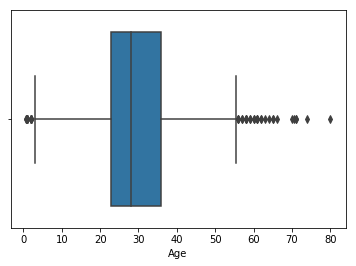

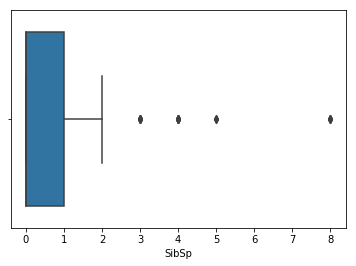

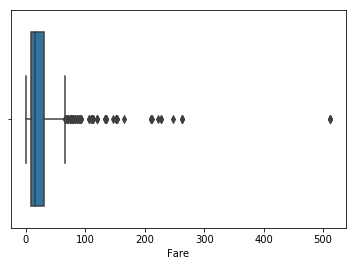

In [ ]:
for name in feature_num:
    try:
        sns.boxplot(X_train[name])
        plt.show()
    except:
        print('для ',name,' ошибка работы')

Законы не похожи на нормальные.
Проверим по тесту нормальности (https://www.machinelearningmastery.ru/a-gentle-introduction-to-normality-tests-in-python/, https://www.machinelearningmastery.ru/statistical-hypothesis-tests-in-python-cheat-sheet/) и проверяем сразу логарифмическое преобразование к нормальному закону по PowerTransformer (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html):

(668, 1)
(668, 1)
(668, 1)


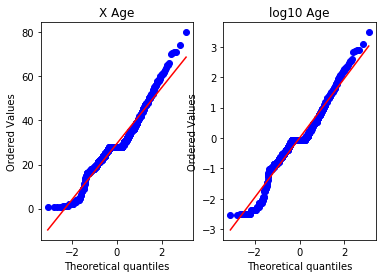

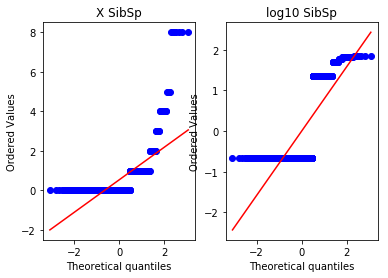

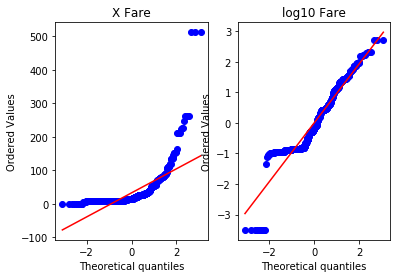

In [ ]:
from scipy import stats
from sklearn.preprocessing import PowerTransformer

for name in feature_num:
    try:
        vPower = PowerTransformer().fit(X_train[name].values.reshape(-1,1)+1)
        yv = vPower.transform(X_train[name].values.reshape(-1,1)+1)
        print(yv.shape)
        fig1, (ax1, ax2) = plt.subplots(1,2)
        p1 = stats.probplot(X_train[name], dist=stats.norm, plot=ax1)
        p2 = stats.probplot(yv[:,0], dist=stats.norm, plot=ax2)
        ax1.set_title('X '+name)
        ax2.set_title('log10 '+name)

    except:
        print('для ',name,' ошибка работы')

Результат : все данные кроме Age не нормальны (далеко от красной линии - хвосты уходят от нее) и применение нормализации к этим данным не помогло slibSp и слабо улучшает результат Fare (для него берем и прямую форму и логарифм)         

Оценим данные в разрезе цели:
    

In [ ]:
X1 =X_train.loc[y_train == 1, :]
X0 =X_train.loc[y_train == 0, :]



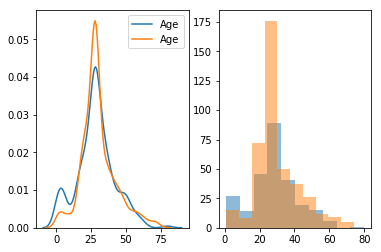

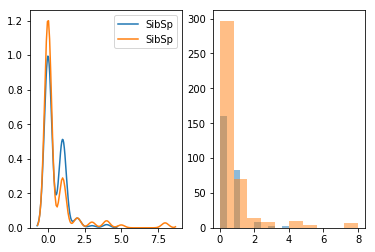

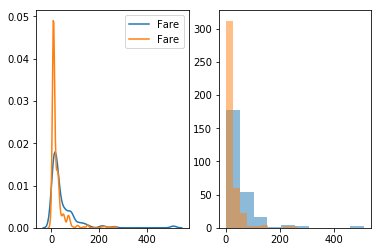

In [ ]:
for name in feature_num:
    try:
        plt.subplot(1,2,1)
        sns.kdeplot(X1[name])
        sns.kdeplot(X0[name])
        plt.subplot(1,2,2)
        plt.hist(X1[name], alpha = 0.5)
        plt.hist(X0[name], alpha = 0.5)
        plt.show()
    except:
        print('для ',name,' ошибка работы')

Есть различия для классов - это хорошо

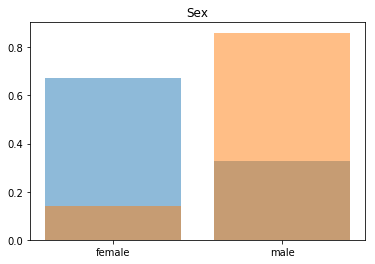

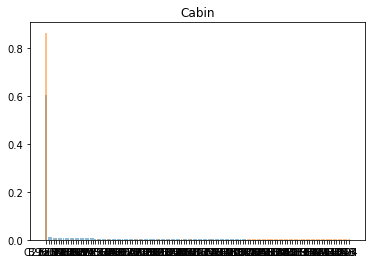

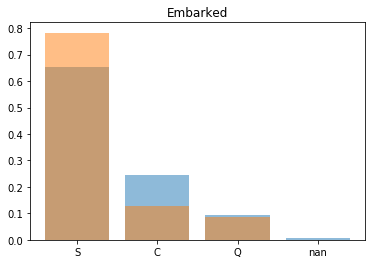

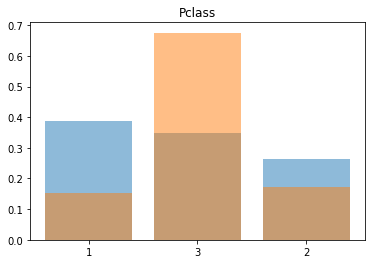

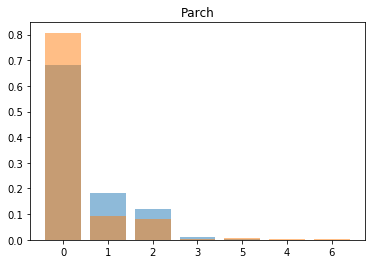

In [ ]:
for name in feature_cat:
    try:
        b1 = X1[name].value_counts(normalize=True)
        b0 = X0[name].value_counts(normalize=True)
        plt.bar(b1.index,b1.values, alpha=0.5)
        plt.bar(b0.index,b0.values, alpha=0.5)
        plt.title(name)
        plt.show()
    except:
        print('для ',name,' ошибка работы')

Вывод:
    - признак Cabin - нужно изменить
    - остальные признаки различают 0 и 1 по цели (частоты для целевого признака = 1 и 0 не совпадают - это хорошо)

### вывод анализа (финал этапа EDA)

1) данные не сбалансированы
2) признак Cabin - обработать
3) признак slibSp и  Fare - сделать powerNransform вариант
4) пропуски Age заменять медианой



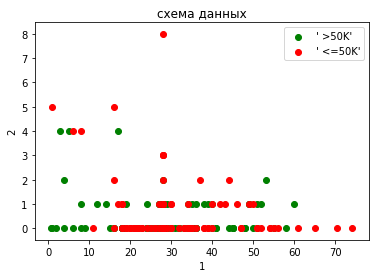

In [ ]:
N100 = 100
n0 = 2
n2 = 3 # 4,10,11,12
plt.scatter(X_train.values[y_train == 1, n0][:N100],X_train.values[y_train == 1, n2][:N100], c="green", label="' >50K'")
plt.scatter(X_train.values[y_train == 0, n0][:N100],X_train.values[y_train == 0, n2][:N100], c="red", label="' <=50K'")
plt.xlabel("1")
plt.ylabel("2")
plt.title("схема данных")
plt.legend();

## Строим признаки

Ссылка : https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing

собираем процедуру для обработки:


**Cabin**

In [ ]:
X_train.loc[X_train['Cabin'].values != 'nan', 'Cabin'][:N100]

820            B69
585            E68
823           E121
698            C68
263            B94
          ...     
88     C23 C25 C27
341    C23 C25 C27
61             B28
429            E10
394             G6
Name: Cabin, Length: 100, dtype: object

In [ ]:
X_train['Cabin_n'] = 0
X_train.loc[X_train['Cabin'].values == 'nan','Cabin_n'] = 1 #фиксируем факт nan в новом признаке

X_train['Cabin_Alf'] = '0'
X_train.loc[X_train['Cabin'].values != 'nan','Cabin_Alf'] = [x.split(' ')[0][0] for x in X_train.loc[X_train['Cabin'].values != 'nan','Cabin'].values]
#фиксируем факт значения в новом признаке
X_train['Cabin_Dig'] = '0'
X_train.loc[X_train['Cabin'].values != 'nan','Cabin_Dig'] = [x.split(' ')[0][1:] for x in X_train.loc[X_train['Cabin'].values != 'nan','Cabin'].values]
#фиксируем факт номера в новом признаке
X_train['Cabin_numb'] = 0
X_train.loc[X_train['Cabin'].values != 'nan','Cabin_numb'] = [len(x.split(' ')) for x in X_train.loc[X_train['Cabin'].values != 'nan','Cabin'].values]
#фиксируем факт числа номеров в новом признаке


In [ ]:
X_train.loc[X_train['Cabin'].values != 'nan',:].head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_n,Cabin_Alf,Cabin_Dig,Cabin_numb
820,1,female,52.0,1,1,93.5000,B69,S,0,B,69,1
585,1,female,18.0,0,2,79.6500,E68,S,0,E,68,1
823,3,female,27.0,0,1,12.4750,E121,S,0,E,121,1
698,1,male,49.0,1,1,110.8833,C68,C,0,C,68,1
263,1,male,40.0,0,0,0.0000,B94,S,0,B,94,1


проверим новые признаки на число категорий:

In [ ]:
for name in ['Cabin_n','Cabin_Alf','Cabin_Dig','Cabin_numb']:
    print('признак ',name,':')
    print(X_train.loc[:, name ].value_counts())

признак  Cabin_n :
1    511
0    157
Name: Cabin_n, dtype: int64
признак  Cabin_Alf :
0    511
C     43
B     33
E     29
D     26
A     14
F      9
G      2
T      1
Name: Cabin_Alf, dtype: int64
признак  Cabin_Dig :
0      511
         6
101      5
33       5
22       5
      ... 
34       1
39       1
80       1
65       1
67       1
Name: Cabin_Dig, Length: 82, dtype: int64
признак  Cabin_numb :
0    511
1    142
2     10
3      5
Name: Cabin_numb, dtype: int64


Cabin_Dig - содержит пропуск (пробел) - заполним его -1
Cabin_Dig - делаем числом, остальные категории.

в Cabin_Alf категории A, F,G, T малочислены, нужно проверить их класс:

In [ ]:
# изменяем Cabin_Dig
X_train.loc[X_train['Cabin_Dig'] == '','Cabin_Dig']  = '-1'
X_train['Cabin_Dig']  = X_train['Cabin_Dig'].astype(int)


In [ ]:
# Cabin_Alf категории A, F,G, T, ....
# считаем нормализованное отношение числа примров каждого типа целей (0 и 1) при значениях Cabin_Alf
# Если частоты близки, то объединим (можно сделать по тесту Chi2)

d = df[target].value_counts(normalize = True).values
for alf in X_train.Cabin_Alf.unique():
    print(alf,' : ',X_train.loc[(y_train == 1)&(X_train.Cabin_Alf == alf) , 'Cabin_Alf'].shape[0]/ d[1] / (X_train.loc[(y_train == 0)&(X_train.Cabin_Alf == alf), 'Cabin_Alf'].shape[0]/ d[0]))

0  :  0.7054114158636026
B  :  5.016447368421053
E  :  5.045112781954887
C  :  2.0277008310249305
D  :  3.611842105263158
A  :  1.2039473684210527
F  :  3.210526315789474
G  :  1.605263157894737
T  :  0.0


Частотный анализ(близкие частоты ):
    - 0 - нет близких
    - В близок Е
    - D близок F
    - G близок A
    - T  добавим к 0

In [ ]:
X_train['Cabin_Alf'].replace({'T':'0','E':'B','F':'D','G':'A'}, inplace = True)
X_train.loc[X_train['Cabin'].values != 'nan',:].head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_n,Cabin_Alf,Cabin_Dig,Cabin_numb
820,1,female,52.0,1,1,93.5000,B69,S,0,B,69,1
585,1,female,18.0,0,2,79.6500,E68,S,0,B,68,1
823,3,female,27.0,0,1,12.4750,E121,S,0,B,121,1
698,1,male,49.0,1,1,110.8833,C68,C,0,C,68,1
263,1,male,40.0,0,0,0.0000,B94,S,0,B,94,1


In [ ]:
# заменеим буквы на цифры
dict_ = {key:i for i,key in enumerate(X_train.Cabin_Alf.unique())}
X_train['Cabin_Alf'].replace(dict_, inplace = True)

Уберем Cabin, т.к. он разобран на части

In [ ]:
X_train.drop('Cabin',axis=1,inplace=True)

Остальные признаки:
    
    Sex - замену на 0/1

In [ ]:
X_train['Sex'].replace({'female':0,'male':1}, inplace = True)

In [ ]:
# заменеим буквы на цифры
dict_ = {key:i for i,key in enumerate(X_train.Embarked.unique())}
X_train['Embarked'].replace(dict_, inplace = True)

In [ ]:
X_train.loc[X_train['Cabin_n'].values != 1,:].head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_n,Cabin_Alf,Cabin_Dig,Cabin_numb
820,1,0,52.0,1,1,93.5000,0,0,1,69,1
585,1,0,18.0,0,2,79.6500,0,0,1,68,1
823,3,0,27.0,0,1,12.4750,0,0,1,121,1
698,1,1,49.0,1,1,110.8833,1,0,2,68,1
263,1,1,40.0,0,0,0.0000,0,0,1,94,1


Вывод:
     - все стало цифрой
     - добавим стандартизацию и соберем функцию препроцессинга данных из сырых   

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class preprocess_data(BaseEstimator, TransformerMixin):
    """
    Transformer to select a single column from the data frame to perform additional transformations on
    """
    def __init__(self):

        self.median_age = 0
        self.AgePower = PowerTransformer()
        self.SPower = PowerTransformer()
        self.FPower = PowerTransformer()
        self.cat = []

    def preproc_X(self,X):
        X['Age'].fillna(self.median_age, inplace = True)
        X['Cabin_n'] = 0
        X.loc[X['Cabin'].values == 'nan','Cabin_n'] = 1 #фиксируем факт nan в новом признаке

        X['Cabin_Alf'] = '0'
        X.loc[X['Cabin'].values != 'nan','Cabin_Alf'] = [x.split(' ')[0][0] for x in X.loc[X['Cabin'].values != 'nan','Cabin'].values]
        #фиксируем факт значения в новом признаке
        X['Cabin_Dig'] = '0'
        X.loc[X['Cabin'].values != 'nan','Cabin_Dig'] = [x.split(' ')[0][1:] for x in X.loc[X['Cabin'].values != 'nan','Cabin'].values]
        #фиксируем факт номера в новом признаке
        X['Cabin_numb'] = 0
        X.loc[X['Cabin'].values != 'nan','Cabin_numb'] = [len(x.split(' ')) for x in X.loc[X['Cabin'].values != 'nan','Cabin'].values]
        #фиксируем факт числа номеров в новом признаке

        # изменяем Cabin_Dig
        X.loc[X['Cabin_Dig'] == '','Cabin_Dig']  = '-1'
        X['Cabin_Dig']  = X['Cabin_Dig'].astype(int)



        X['Cabin_Alf'].replace({'T':'0','E':'B','F':'D','G':'A'}, inplace = True)

        # заменеим буквы на цифры
        dict_ = {key:i for i,key in enumerate(X.Cabin_Alf.unique())}
        X['Cabin_Alf'].replace(dict_, inplace = True)

        X['Sex'].replace({'female':'0','male':'1'}, inplace = True)

        # заменеим буквы на цифры
        dict_ = {key:i for i,key in enumerate(X.Embarked.unique())}
        X['Embarked'].replace(dict_, inplace = True)
        return X

    def fit(self, X, y=None):
        self.cat = [feat for feat in X.columns if X[feat].dtype not in ['int64','float64']] + ['Pclass','Parch']
        feature_num = [ 'Age', 'SibSp',  'Fare']
        X.loc[:, self.cat] = X.loc[:, self.cat].astype(str)

        X = self.preproc_X(X)
        self.AgePower.fit(X['Age'].values.reshape(-1,1)+1)
        self.SPower.fit(X['SibSp'].values.reshape(-1,1)+1)
        self.FPower.fit(X['Fare'].values.reshape(-1,1)+1)
        self.median_age = X[imputer_list[0]].median()

        return self

    def transform(self, X):
        X.loc[:, self.cat] = X.loc[:, self.cat].astype(str)
        X = self.preproc_X(X)

        X['Age']=self.AgePower.transform(X['Age'].values.reshape(-1,1)+1)
        X['SibSp'] = self.SPower.transform(X['SibSp'].values.reshape(-1,1)+1)
        X['Fare'] = self.FPower.transform(X['Fare'].values.reshape(-1,1)+1)
        X.drop('Cabin',axis=1,inplace=True)


        return X

Проверка на сырых данных:

In [ ]:
df = pd.read_csv(path + "titanic_train.csv", sep = ',')
dfv = df.copy()
ddd  = preprocess_data()
XX  = ddd.fit_transform(dfv.loc[:,features])
XX.head()




,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_n,Cabin_Alf,Cabin_Dig,Cabin_numb
0,3,1,0.079290,1.351812,0,-0.915980,0,1,0,0,0
1,1,0,0.824609,1.351812,0,1.355050,1,0,1,85,1
2,3,0,0.281034,-0.678683,0,-0.820343,0,1,0,0,0
3,1,0,0.695834,1.351812,0,1.100537,0,0,1,123,1
4,3,1,0.695834,-0.678683,0,-0.803505,0,1,0,0,0


Проверка прошла. Все работает.


## Строим модель

In [ ]:
# 1 - формируем данные
features = [  'Pclass',  'Sex', 'Age', 'SibSp',
       'Parch',  'Fare', 'Cabin', 'Embarked']
target = 'Survived'


#разделим данные на train/test
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], random_state=0)
#создаем препроцессоры данных
trans_data = preprocess_data()
sc = StandardScaler()

# обучаем части препроцессора данных
X_train_trans  = trans_data.fit_transform(X_train)
sc.fit(X_train_trans)

# применяем препроцессоры данных
X_train_trans = sc.transform(X_train_trans)
X_test_trans = sc.transform(trans_data.transform(X_test))


In [ ]:
X_train.shape,y_train.shape

((668, 11), (668,))

### Собираем модели:

Типы классификаторов:
Первичный выбор делаем на моделях разных классов:
     - Случайный лес (from sklearn.ensemble import RandomForestClassifier )
     - Градиентный бустинг (from sklearn.ensemble import GradientBoostingClassifier)
     - К ближайший сосед from sklearn.neighbors import KNeighborsClassifier
     - Логистическая регрессияfrom sklearn.linear_model import LogisticRegression
     - SVM (from sklearn.svm import SVC)
     
     
Ссылки :
- логистическая регрессия http://www.machinelearning.ru/wiki/index.php?title=%D0%9B%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F
- деревья,  http://www.machinelearning.ru/wiki/images/3/3e/Voron-ML-Logic.pdf
- леса,  бустинг http://www.machinelearning.ru/wiki/images/0/0d/Voron-ML-Compositions.pdf
- метрические модели (KNN) http://www.machinelearning.ru/wiki/images/c/c3/Voron-ML-Metric-slides.pdf
- SVM http://www.machinelearning.ru/wiki/images/a/a0/Voron-ML-Lin-SVM.pdf

In [ ]:



RF =  RandomForestClassifier()
GB = GradientBoostingClassifier()
KNN = KNeighborsClassifier()
LM = LogisticRegression()
SV = SVC(gamma='auto',probability=True)
cls_= ['RF','GB','KNN','LM','SV']

list_class = {"cls":[RF,GB,KNN,LM,SV],'metric':[0,0,0,0,0]}

**Первичная селекция моделей**

RF : : 0.8875471051730044
GB : : 0.8800959232613909
KNN : : 0.8108084960602946
LM : : 0.8635234669407331
SV : : 0.849049331963001


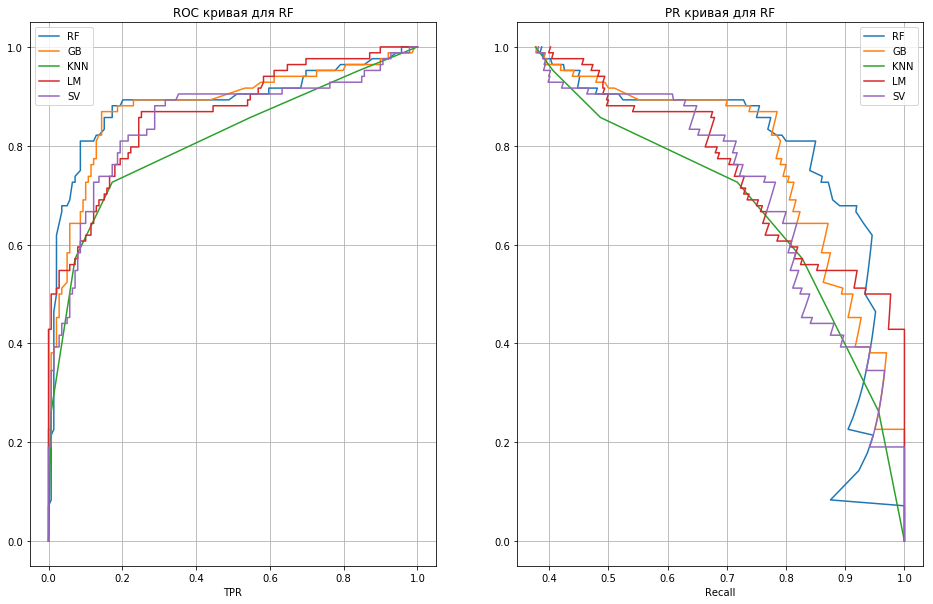

In [ ]:
plt.figure(figsize =(16,10))
for i,model in enumerate(list_class["cls"]):
    yp = model.fit(X_train_trans,y_train).predict_proba(X_test_trans)[:,1]
    list_class['metric'][i] = roc_auc_score(y_test,yp)
    p,r,t = roc_curve(y_test,yp)
    plt.subplot(1,2,1)
    plt.plot(p,r,label = cls_[i])
    p,r,t = precision_recall_curve(y_test,yp)
    plt.subplot(1,2,2)
    plt.plot(p,r,label = cls_[i])
    print(cls_[i],": :",list_class['metric'][i])
plt.subplot(1,2,1)
plt.title('ROC кривая для RF')
plt.grid(True)
plt.xlabel('FPR')
plt.xlabel('TPR')
plt.legend()
plt.subplot(1,2,2)
plt.title('PR кривая для RF')
plt.grid(True)
plt.xlabel('Precision')
plt.xlabel('Recall')
plt.legend()
plt.show()



Случайный лес - лучше всех: строим случайные леса
    
    - чем больше метрика - тем лучше (0.89 - хорошо)
    - однако модели SVM, LM и GB тоже неплохо выглядят.
    - есть смысл посмотреть и на них с гиперпараметрами
    - на KNN не смотрим - слишком плох
    
    - выборка плохо сбалансирована - смотрим на точность/полноту (тут лучшие RF  и GB)
    
    
### Строим модель с подбором гиперпараметров    

Делаем сеточный поиск:

**Самостоятельно посмотреть на сеточный и случайный поиск с корсс-вавлидацией и без в sklearn sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, RandomSearch, GridSearch,  RandomSearchCV**


Провести собственные эксперименты: не менне 10 -15 моделей в сравнении

In [ ]:
rez = np.zeros((10,10))

for i,n_tree in enumerate(np.linspace(1,500,10)): # варианты числа деревьев
    for j,deep_tree in enumerate(np.linspace(1,10,10)): # варианты глубины деревьев
        RF =  RandomForestClassifier(max_depth=int(deep_tree),n_estimators=int(n_tree))
        yp = RF.fit(X_train_trans,y_train).predict_proba(X_test_trans)[:,1]
        rez[i,j] = roc_auc_score(y_test,yp) # сохраняем метрику на отложенной выборке
        del RF


**Визуализация RF:**

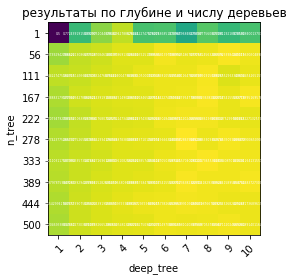

In [ ]:
def plot_rez(rez,xlabel,ylabel,title,xyl = [[1,500],[1,10]]):

    fig, ax = plt.subplots()

    im = ax.imshow(rez)
    n = rez.shape
    # We want to show all ticks...
    ax.set_xticks(np.arange(n[1]))
    ax.set_yticks(np.arange(n[0]))
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    # ... and label them with the respective list entries
    ax.set_yticklabels(np.linspace(xyl[0][0],xyl[0][1],n[0]).astype(int))
    ax.set_xticklabels(np.linspace(xyl[1][0],xyl[1][1],n[1]).astype(int))

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    for i in range(n[0]):
        for j in range(n[1]):
            text = ax.text(j, i, rez[i, j],
                           ha="center", va="center", color="w",size=3)

    ax.set_title("результаты по глубине и числу деревьев")
    fig.tight_layout()
    plt.show()
plot_rez(rez,'deep_tree','n_tree','ROC_AUC от числа деревьев и их глубины',xyl = [[1,500],[1,10]])

Выводы:
    - первичный сеточный поиск показал, что достаточно 10-50 деревьев при глубине выше 6 уровней
    - нужно уменьшить интервал до 10 деревьев и пройти еще раз поиск гиперпаратметров
    - нужно построить аналогичные результаты для 3-х оставшихся моделей^
        - выбрать для каждого типа моделей 2 гиперпараметра (см.документацию sklearn)
        - сделать сеточный поиск по этим 2м параметрам для 3-х классов моделей
        - сравнить результаты и сделать выводы
    
    

### Строим финальную модель:

    - строим модель с гиперпараметрами из поиска гиперпараметров
    - калибруем модель

In [ ]:
RF =  RandomForestClassifier(max_depth=int(deep_tree),n_estimators=int(n_tree))
yp = RF.fit(X_train_trans,y_train).predict_proba(X_test_trans)[:,1]
print(roc_auc_score(y_test,yp))

0.8936279547790339


### Feature Engeeniring
### Можно попробовать сделать новые признаки:
    - полиномиальные
    - просто разные варианты сочетаний
    - придумать еще что-то
    
Ссылка:
    книга по построению и оценке признаков - https://www.repath.in/gallery/feature_engineering_for_machine_learning.pdf

### Создадим объект sklearn, который добавит в матрицу  𝑋  полиномиальные признаки вплоть до степени 2.

In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train_trans)
X_poly_test = poly.transform(X_test_trans)


In [ ]:
X_poly.shape

(668, 78)

In [ ]:
RF =  RandomForestClassifier(max_depth=int(deep_tree),n_estimators=int(n_tree))
yp = RF.fit(X_poly,y_train).predict_proba(X_poly_test)[:,1]
print(roc_auc_score(y_test,yp))

0.8878468653648509


### Балансировка выборки

- добавить примеров малого класса
- убрать примероы большого класса
- сделать искусственных примеров


Добавим примеров из класса 1 (просто дублируем ) - oversampling


In [ ]:
N1 = sum(y_train==1)
N0 = sum(y_train==0)
print(X_poly.shape)
dN = N0-N1
ind_oversampling = np.where(y_train==1)[0]
X_copy = X_poly[ind_oversampling,:].copy()

indi = np.random.randint(0,ind_oversampling.shape[0], dN)
X_poly = np.hstack([X_poly,X_copy[indi,:]])
y_train = np.hstack([y_train,np.ones((indi))])
print(indi.shape[0],X_poly.shape)

(152,)

In [ ]:
print(X_poly.shape)

(668, 78)


In [ ]:
X_poly = np.vstack([X_poly,X_copy[indi[:],:]])

In [ ]:

y_train = np.hstack([y_train,np.ones((indi.shape[0],))])
print(X_poly.shape, y_train.shape)

(820, 78) (820,)


In [ ]:
RF =  RandomForestClassifier(max_depth=int(deep_tree),n_estimators=int(n_tree))
yp = RF.fit(X_poly,y_train).predict_proba(X_poly_test)[:,1]
print(roc_auc_score(y_test,yp))

0.8827081192189107


Стало хуже . Попробуем сделать отбор признаков.


### Селекция признаков и моделей

смотреть источник:
http://www.machinelearning.ru/wiki/images/2/2d/Voron-ML-Modeling.pdf

смотреть документацию sklearn:
https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection

    
 - Для простых моделей  (линейных ) - коэффициент у признака == его значимость
 - некоторые модели умеют строить важность признака (случайный лес, деревья, градиентный бустинг) - свойство .feature_importances_
 - метод проверки, как работает при изменении связи признака с целью (перемешать значения признака - распределение осталось, но связь с целевым уйдет)sklearn.inspection.permutation_importance
 - проверка как работает без признака from sklearn.feature_selection import VarianceThreshold
 - выбрать к лучших признаков: from sklearn.feature_selection import SelectKBest
 - рекурсивная оценка признаков (дорогой метод) from sklearn.feature_selection import RFE
 - использоваине моделей для оценки : from sklearn.feature_selection import SelectFromModel


**Важность признака по модели**

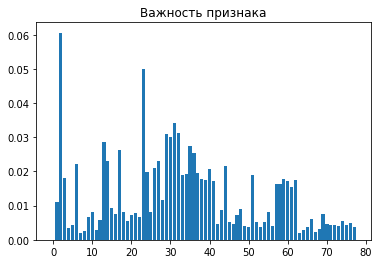

список важных признаков : [ 2  6 13 14 17 23 26 27 29 30 31 32 35 36 40 44]


In [ ]:
plt.bar(list(range(X_poly.shape[1])),RF.feature_importances_)
plt.title('Важность признака')
plt.show()
print('список важных признаков :',np.where(RF.feature_importances_>0.02)[0])

**Отбор по связям с целью - ADD**

In [ ]:
from sklearn.feature_selection import RFE
# создаем RFE объект
SV = SVC(kernel="linear", C=1)
rfe = RFE(estimator=SV, n_features_to_select=1, step=1)
rfe.fit(X_poly,y_train)
ranking = rfe.ranking_
print('список 10 наиболее важных признаков :',ranking[:10])

список 10 наиболее важных признаков : [78 33  1 25  4 18 30 74 14 70]


**Отбор по корреляционным (частотным) связям**

In [ ]:
from sklearn.feature_selection import chi2,f_classif
from sklearn.feature_selection import SelectKBest
# создаем  объект
skb = SelectKBest(f_classif, k=10)
X_skb = skb.fit_transform(X_poly,y_train)
print(X_skb.shape)
print('список 10 наиболее важных признаков :',np.where(skb.get_support())[:10])



(820, 10)
список 10 наиболее важных признаков : (array([ 1,  2,  6,  8,  9, 11, 17, 23, 68, 71], dtype=int64),)


Вывод:
    
    - берем признаки преесечения разных методов (или если их не много, то объединение)
    - в примере set([78 25  3 24  1 30 44 52  9 63]+[78 27  1 32 55 33 60 47 13 45 ]+[ 1,  2,  6,  8,  9, 10, 11, 23, 68, 71])

In [ ]:
new_X_list = set((ranking[:10]-1).tolist()+np.where(skb.get_support())[0][:10].tolist()+np.where(RF.feature_importances_>0.02)[0].tolist())

print(new_X_list )

{0, 1, 2, 3, 6, 8, 9, 11, 13, 14, 17, 23, 24, 26, 27, 29, 30, 31, 32, 35, 36, 40, 44, 68, 69, 71, 73, 77}


**Самостоятельно посмотреть на отбор - пермутация(sklearn.inspection.permutation_importance ) и отбор через модель (from sklearn.feature_selection import SelectFromModel)**

In [ ]:
X_new = X_poly[:,np.array(list(new_X_list))-1]
X_new_test = X_poly_test[:,np.array(list(new_X_list))-1]

X_new.shape

(820, 28)

In [ ]:
rez = np.zeros((10,10))

for i,n_tree in enumerate(np.linspace(1,500,10)): # варианты числа деревьев
    for j,deep_tree in enumerate(np.linspace(1,10,10)): # варианты глубины деревьев
        RF =  RandomForestClassifier(max_depth=int(deep_tree),n_estimators=int(n_tree))
        yp = RF.fit(X_new,y_train).predict_proba(X_new_test)[:,1]
        rez[i,j] = roc_auc_score(y_test,yp) # сохраняем метрику на отложенной выборке
        del RF

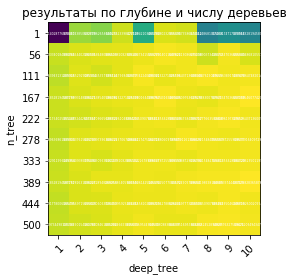

In [ ]:
plot_rez(rez,'deep_tree','n_tree','ROC_AUC от числа деревьев и их глубины',xyl = [[1,500],[1,10]])

Вывод:
    - наиболее продуктивный интервал 8-10 уровней глубины на 350-500 деревьях

In [ ]:
RF =  RandomForestClassifier(max_depth=int(9),n_estimators=int(420))
yp = RF.fit(X_poly,y_train).predict_proba(X_poly_test)[:,1]
print(roc_auc_score(y_test,yp))

0.8862624186365193


In [ ]:
p,r,t = roc_curve(y_test,yp)

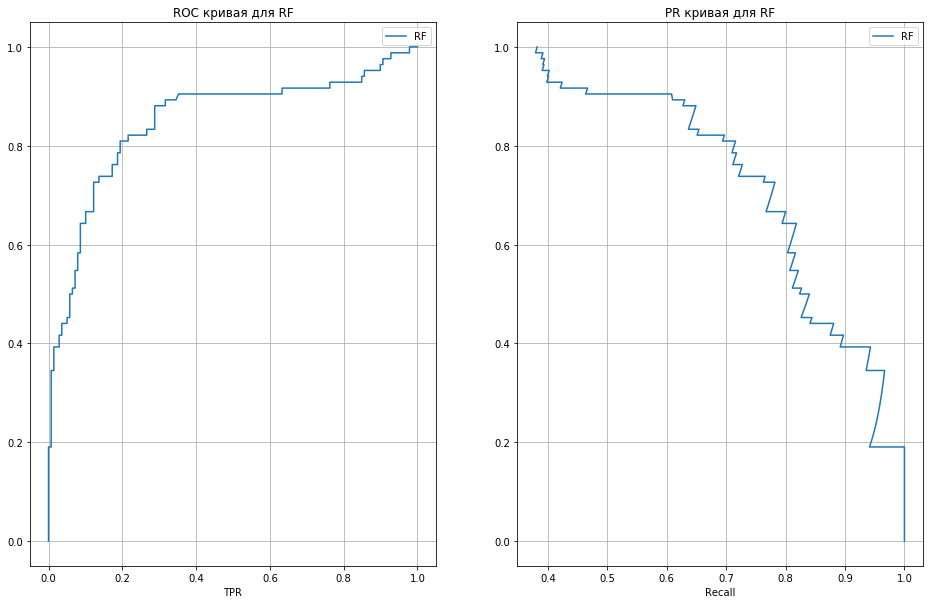

In [ ]:
plt.figure(figsize =(16,10))


p,r,t = roc_curve(y_test,yp)

plt.subplot(1,2,1)

plt.plot(p,r,label = cls_[0])

p,r,t = precision_recall_curve(y_test,yp)

plt.subplot(1,2,2)
plt.plot(p,r,label = cls_[0])

plt.subplot(1,2,1)
plt.title('ROC кривая для RF')
plt.grid(True)
plt.xlabel('FPR')
plt.xlabel('TPR')
plt.legend()
plt.subplot(1,2,2)
plt.title('PR кривая для RF')
plt.grid(True)
plt.xlabel('Precision')
plt.xlabel('Recall')
plt.legend()
plt.show()

### Калибровка модели

Модель построена . Ее можно откалибровать по метрике типа f1_score:
    
    - выбираем порог максимизирующий f1
    
    

0.22858323069238148


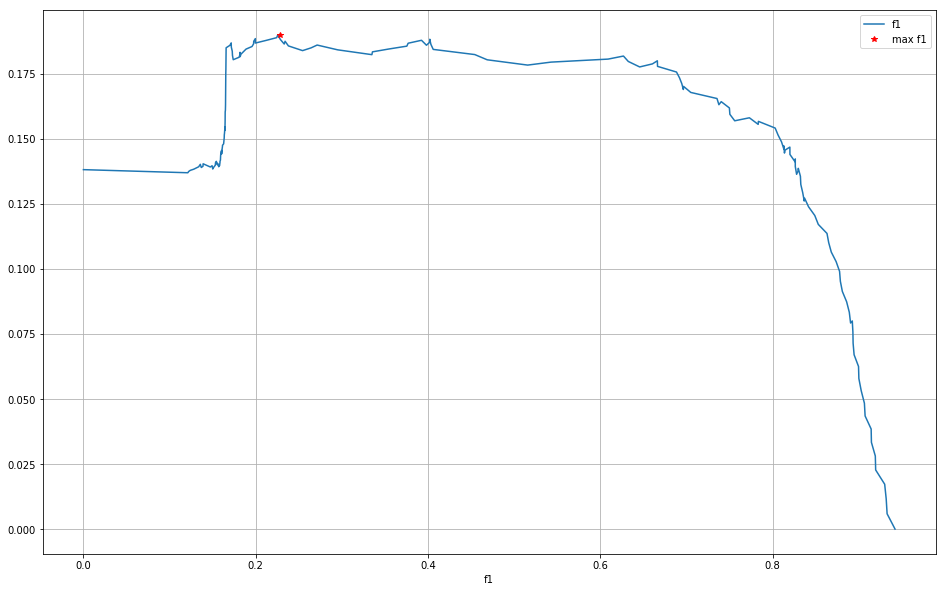

In [ ]:
p,r,t = precision_recall_curve(y_test,yp)

f1 = p*r/2/(p+r)

ind_tr = np.argmax(f1)
print(t[ind_tr])

plt.figure(figsize =(16,10))
plt.plot([0]+t.tolist(),f1, label = 'f1')
plt.plot(t[ind_tr],f1[ind_tr],'*r', label = 'max f1')
plt.xlabel('treshold')
plt.xlabel('f1')
plt.legend()
plt.grid(True)
plt.show()



Наилучший ответ по точности/полноте пришел от порога t[ind_tr]

###  Сохранение модели

Можем сохранить модель для других примеров:
    - создадим процедуру обработки
    - сохраним объекты модели (pikle)
    

In [ ]:
#делим на блоки

### Последовательный анализ задачи:
- провести анализ данных
- построить разные варианты признаков:
  - сделать построение категорийных признаков как непрерывных или бинарных
  - сделать непрерывные признаки сложными
  - сделать непрерывные признаки дискретными
  - сделать эмбединги
  - изменить характер распределения непрерывных признаков
  - построить полиномиальные комбинации признаков
  -
- сделать селекцию признаков
- Сделать первичные модели
- Провести селекцию моделей
- провести поиск гиперпараметров
- построить финальную модель
- откалибровать финальную модель
- оценить результаты решения тестовых наборов

- Все этапы завершить выводом
- сделать общий вывод по итогам анализа


задание 1
- прочитать данные по варианту и провести их анализ (EDA)
- провести этап очистки данных и заполнить пропуски (см. методы анализа выбросов и заполнения пропусков)

Отчет по заданию 1:

    - схема обработки в ноутбуке с комментариями
    - визуализация распредлений
    - оценка линейной связи признаков между собой и с целевым признаком (взаимные парные корреляции)
    - описать методы заполнения пропусков и исправления ошибок (выбросов) - обосновать. методы: константная замена, удаление признаков или объектов, использовыание сложных методов заполнения пропусков

задание 2

- построить признаки на основе текущих (логарифмические преобразования, дамми-кодирование, объединение категорий )
- построить признаки на основе комплексов из текущих признаков (полиномиальные, РСА)
- провести анализ новых признаков (их связи между собой и с целевым свойством)

Отчет по заданию 2:

    - схема обработки в ноутбуке с комментариями
    - визуализация распредлений новых признаков
    - оценка линейной связи новых признаков между собой и с целевым признаком (взаимные парные корреляции)
    - обосновать методы преобразования признаков

Задание 3

- селекция признаков
- оценка сбалансированности выборки и ее балансировка

Отчет по заданию 3:

    - схема обработки в ноутбуке с комментариями
    - обосновать способ отбора признаков

задание 4

 - построить набор первичных моделей
 - провести селекцию моделей (оценки ROC_AUC)
 - провести генерацию гиперпараметров и калибровку модели
 - оценить результат


Отчет по заданию 4:

    - схема обработки в ноутбуке с комментариями
    - обосновать способ отбора моделей
    